In [3]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

import warnings 
warnings.filterwarnings("ignore")

df = pd.read_csv('../data/telco.csv')
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [4]:
# Create a copy of the original dataframe
df_processed = df.copy()


In [5]:
columns_to_drop = [
    'Customer ID',
    'Country',
    'State',
    'Quarter',
    'Customer Status',
    'Churn Score',
    'Churn Category',
    'Churn Reason',
    'CLTV',
    'City',
    'Zip Code',
    'Total Revenue'
]

df_processed.drop(columns=columns_to_drop, inplace=True)

print(df_processed.shape)

(7043, 38)


In [6]:
df_processed['Offer'] = df_processed['Offer'].fillna('No Offer')

df_processed['Internet Type'] = (
    df_processed['Internet Type']
    .fillna('No Internet Service')
)

In [7]:
df_processed[['Offer', 'Internet Type']].isnull().sum()

Offer            0
Internet Type    0
dtype: int64

In [8]:
df_processed['Churn Label'] = (
    df_processed['Churn Label']
    .map({'Yes': 1, 'No': 0})
)

In [9]:
X = df_processed.drop('Churn Label', axis=1)
y = df_processed['Churn Label']

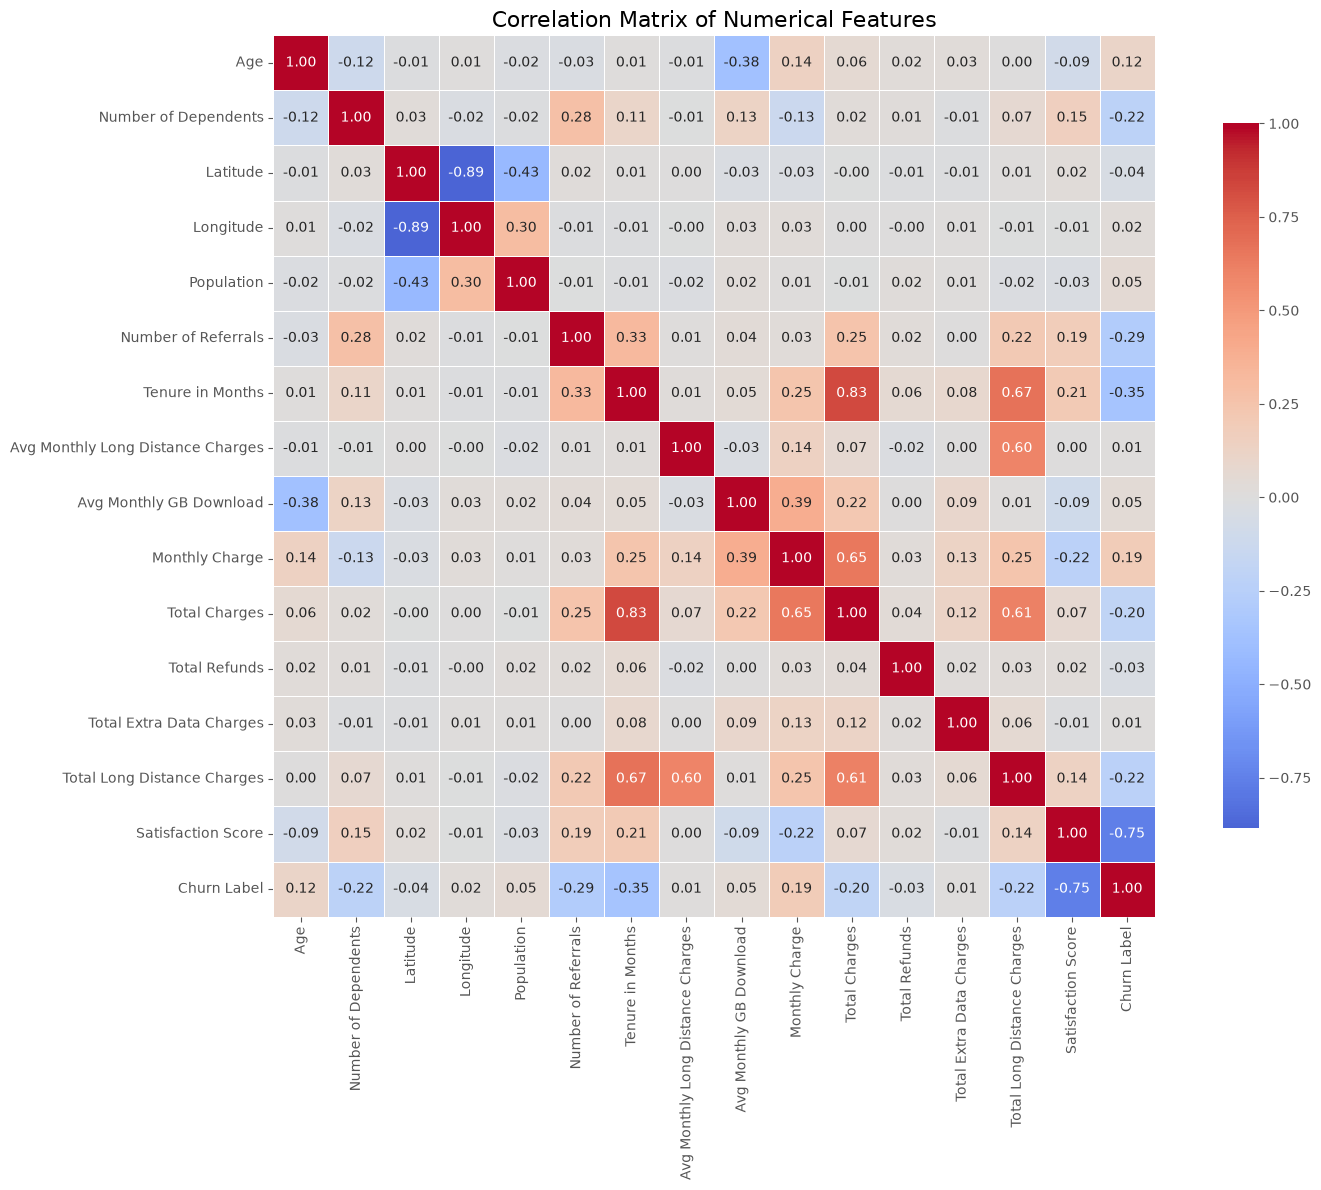

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_processed.corr(numeric_only=True)

# Select only numerical columns
corr_matrix = df_processed.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Numerical Features", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [11]:
categorical_cols = X.select_dtypes(include='object').columns

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print(X.shape)

(7043, 45)


In [12]:
print(X.info())

print()

print(y.value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 45 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Number of Dependents               7043 non-null   int64  
 2   Latitude                           7043 non-null   float64
 3   Longitude                          7043 non-null   float64
 4   Population                         7043 non-null   int64  
 5   Number of Referrals                7043 non-null   int64  
 6   Tenure in Months                   7043 non-null   int64  
 7   Avg Monthly Long Distance Charges  7043 non-null   float64
 8   Avg Monthly GB Download            7043 non-null   int64  
 9   Monthly Charge                     7043 non-null   float64
 10  Total Charges                      7043 non-null   float64
 11  Total Refunds                      7043 non-null   float64
 12  Tot

In [13]:
processed_data = X.copy()
processed_data["Churn Label"] = y

processed_data.to_csv(
    "Preprocessed.csv",
    index=False
)

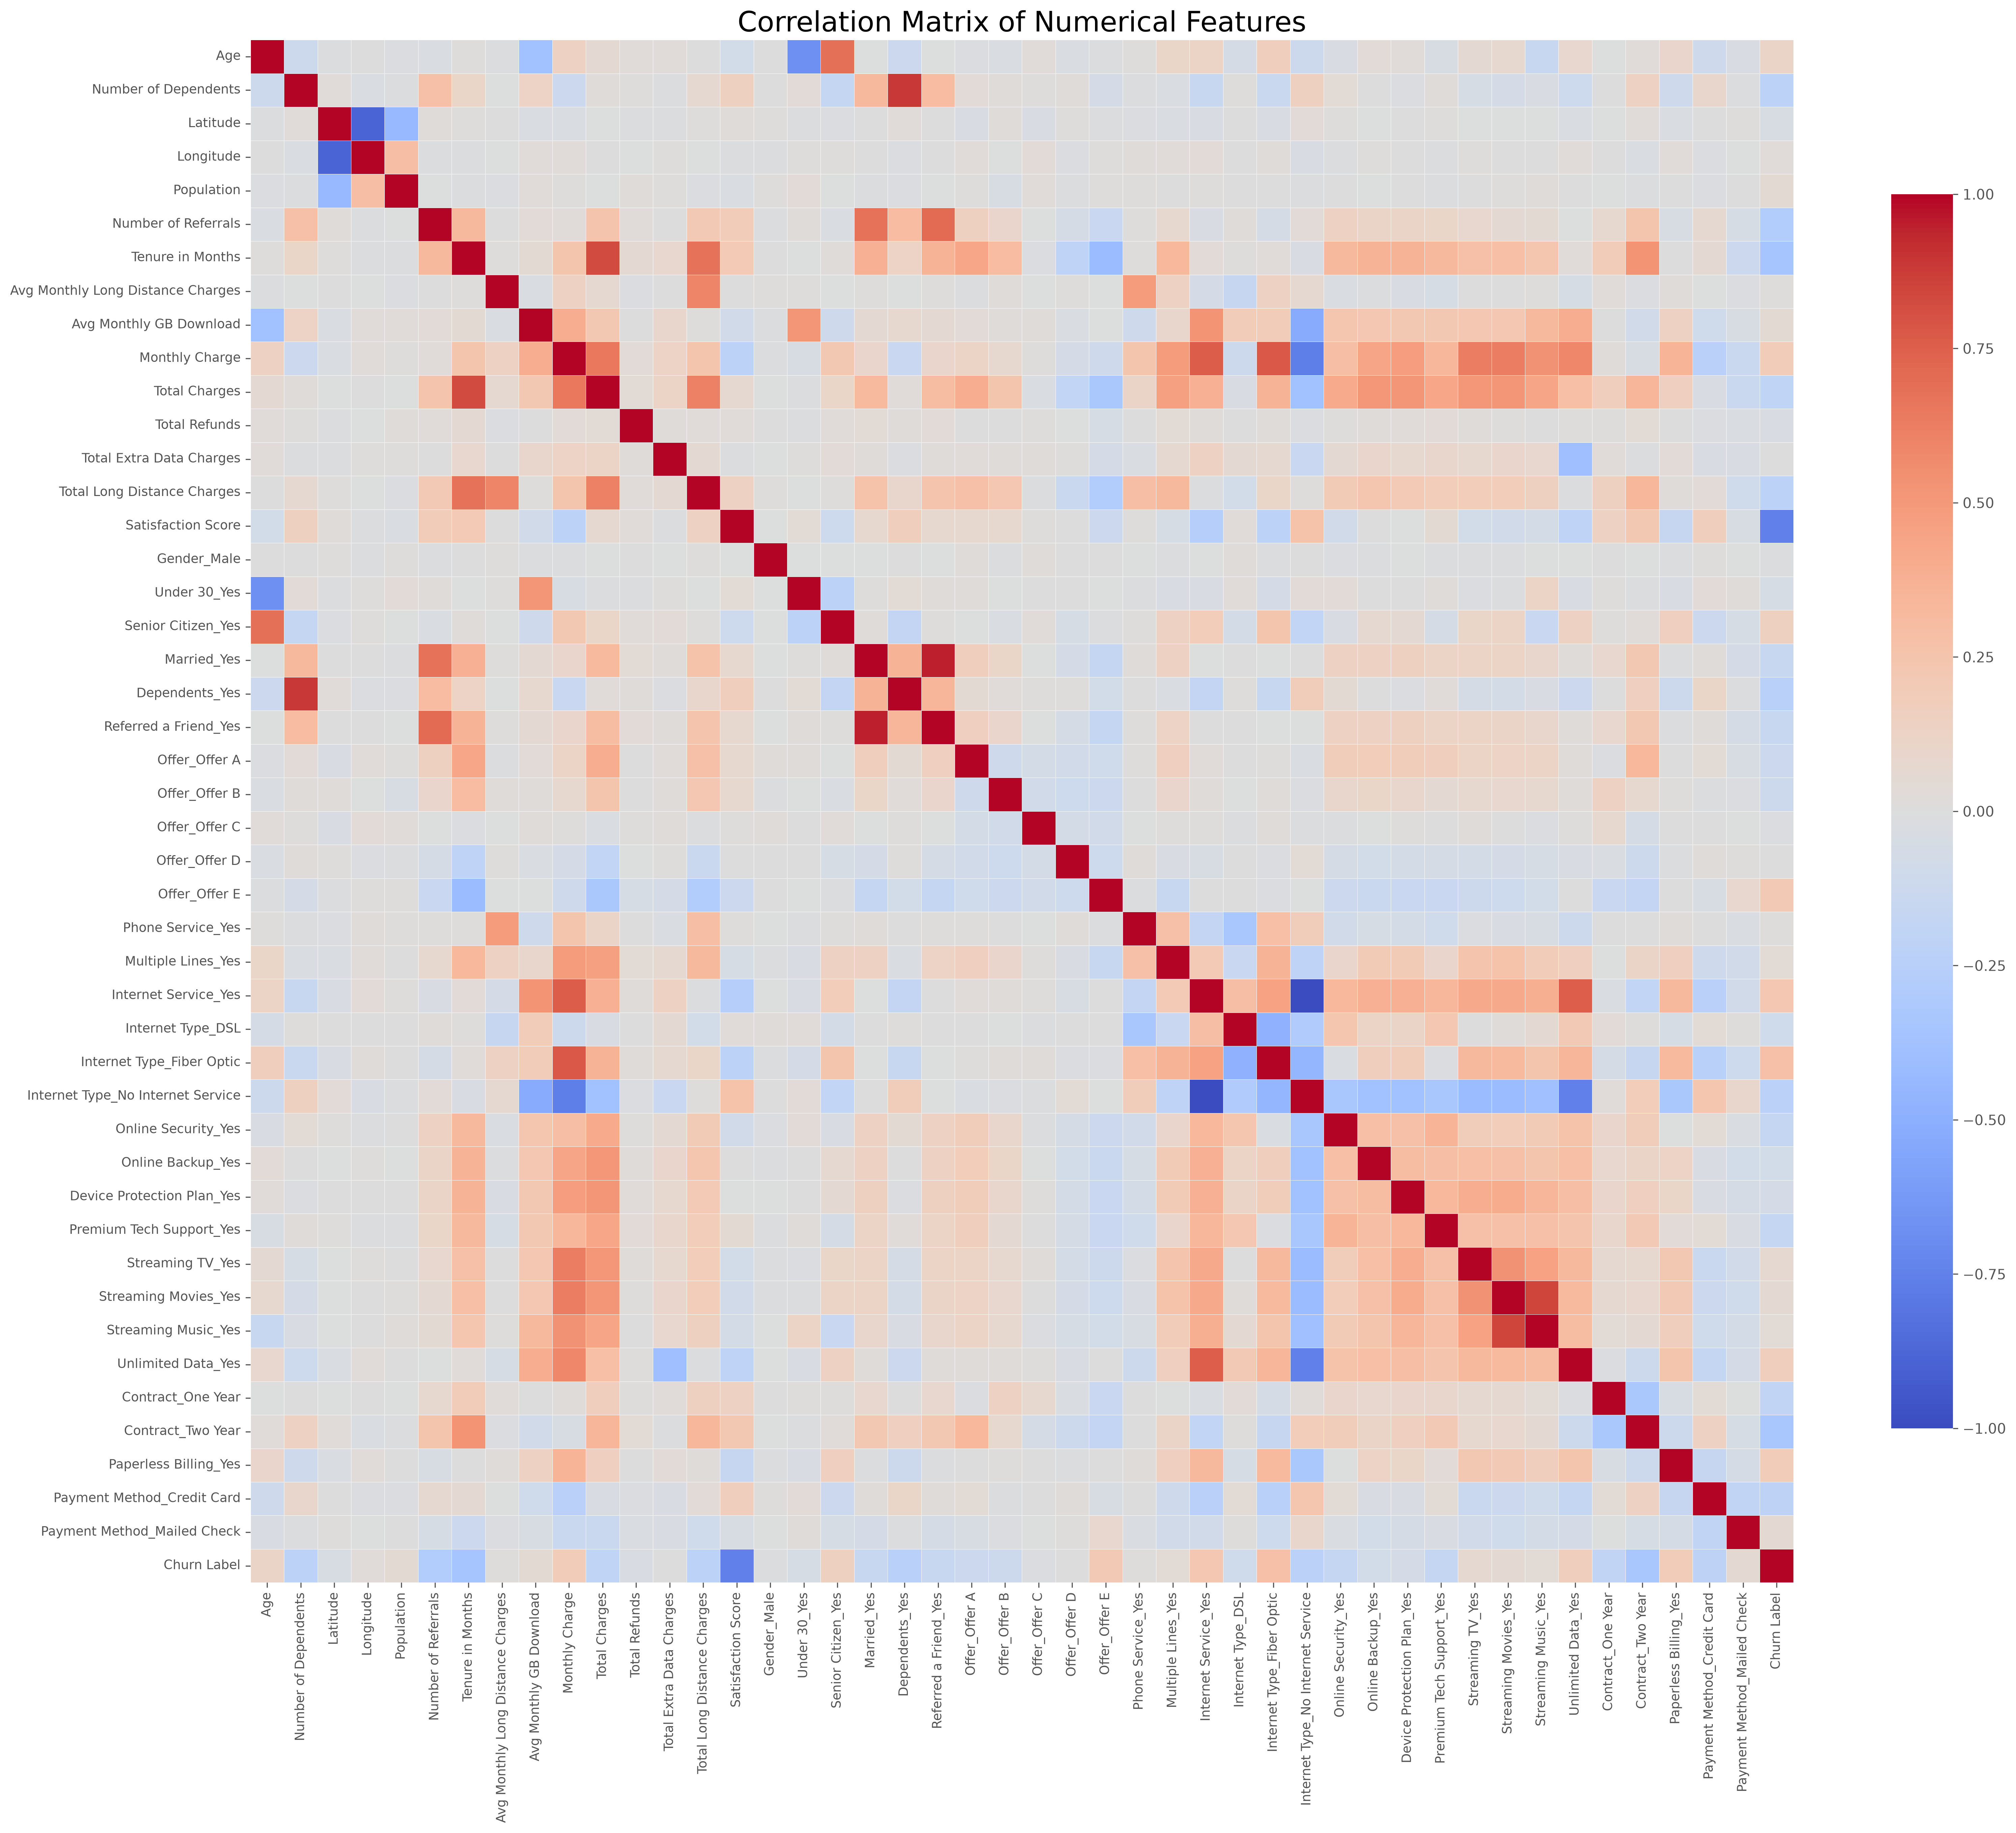

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = processed_data.corr(numeric_only=True)

plt.figure(figsize=(22, 18), dpi=300)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink":0.8},
    annot=False
)

plt.title("Correlation Matrix of Numerical Features", fontsize=20)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

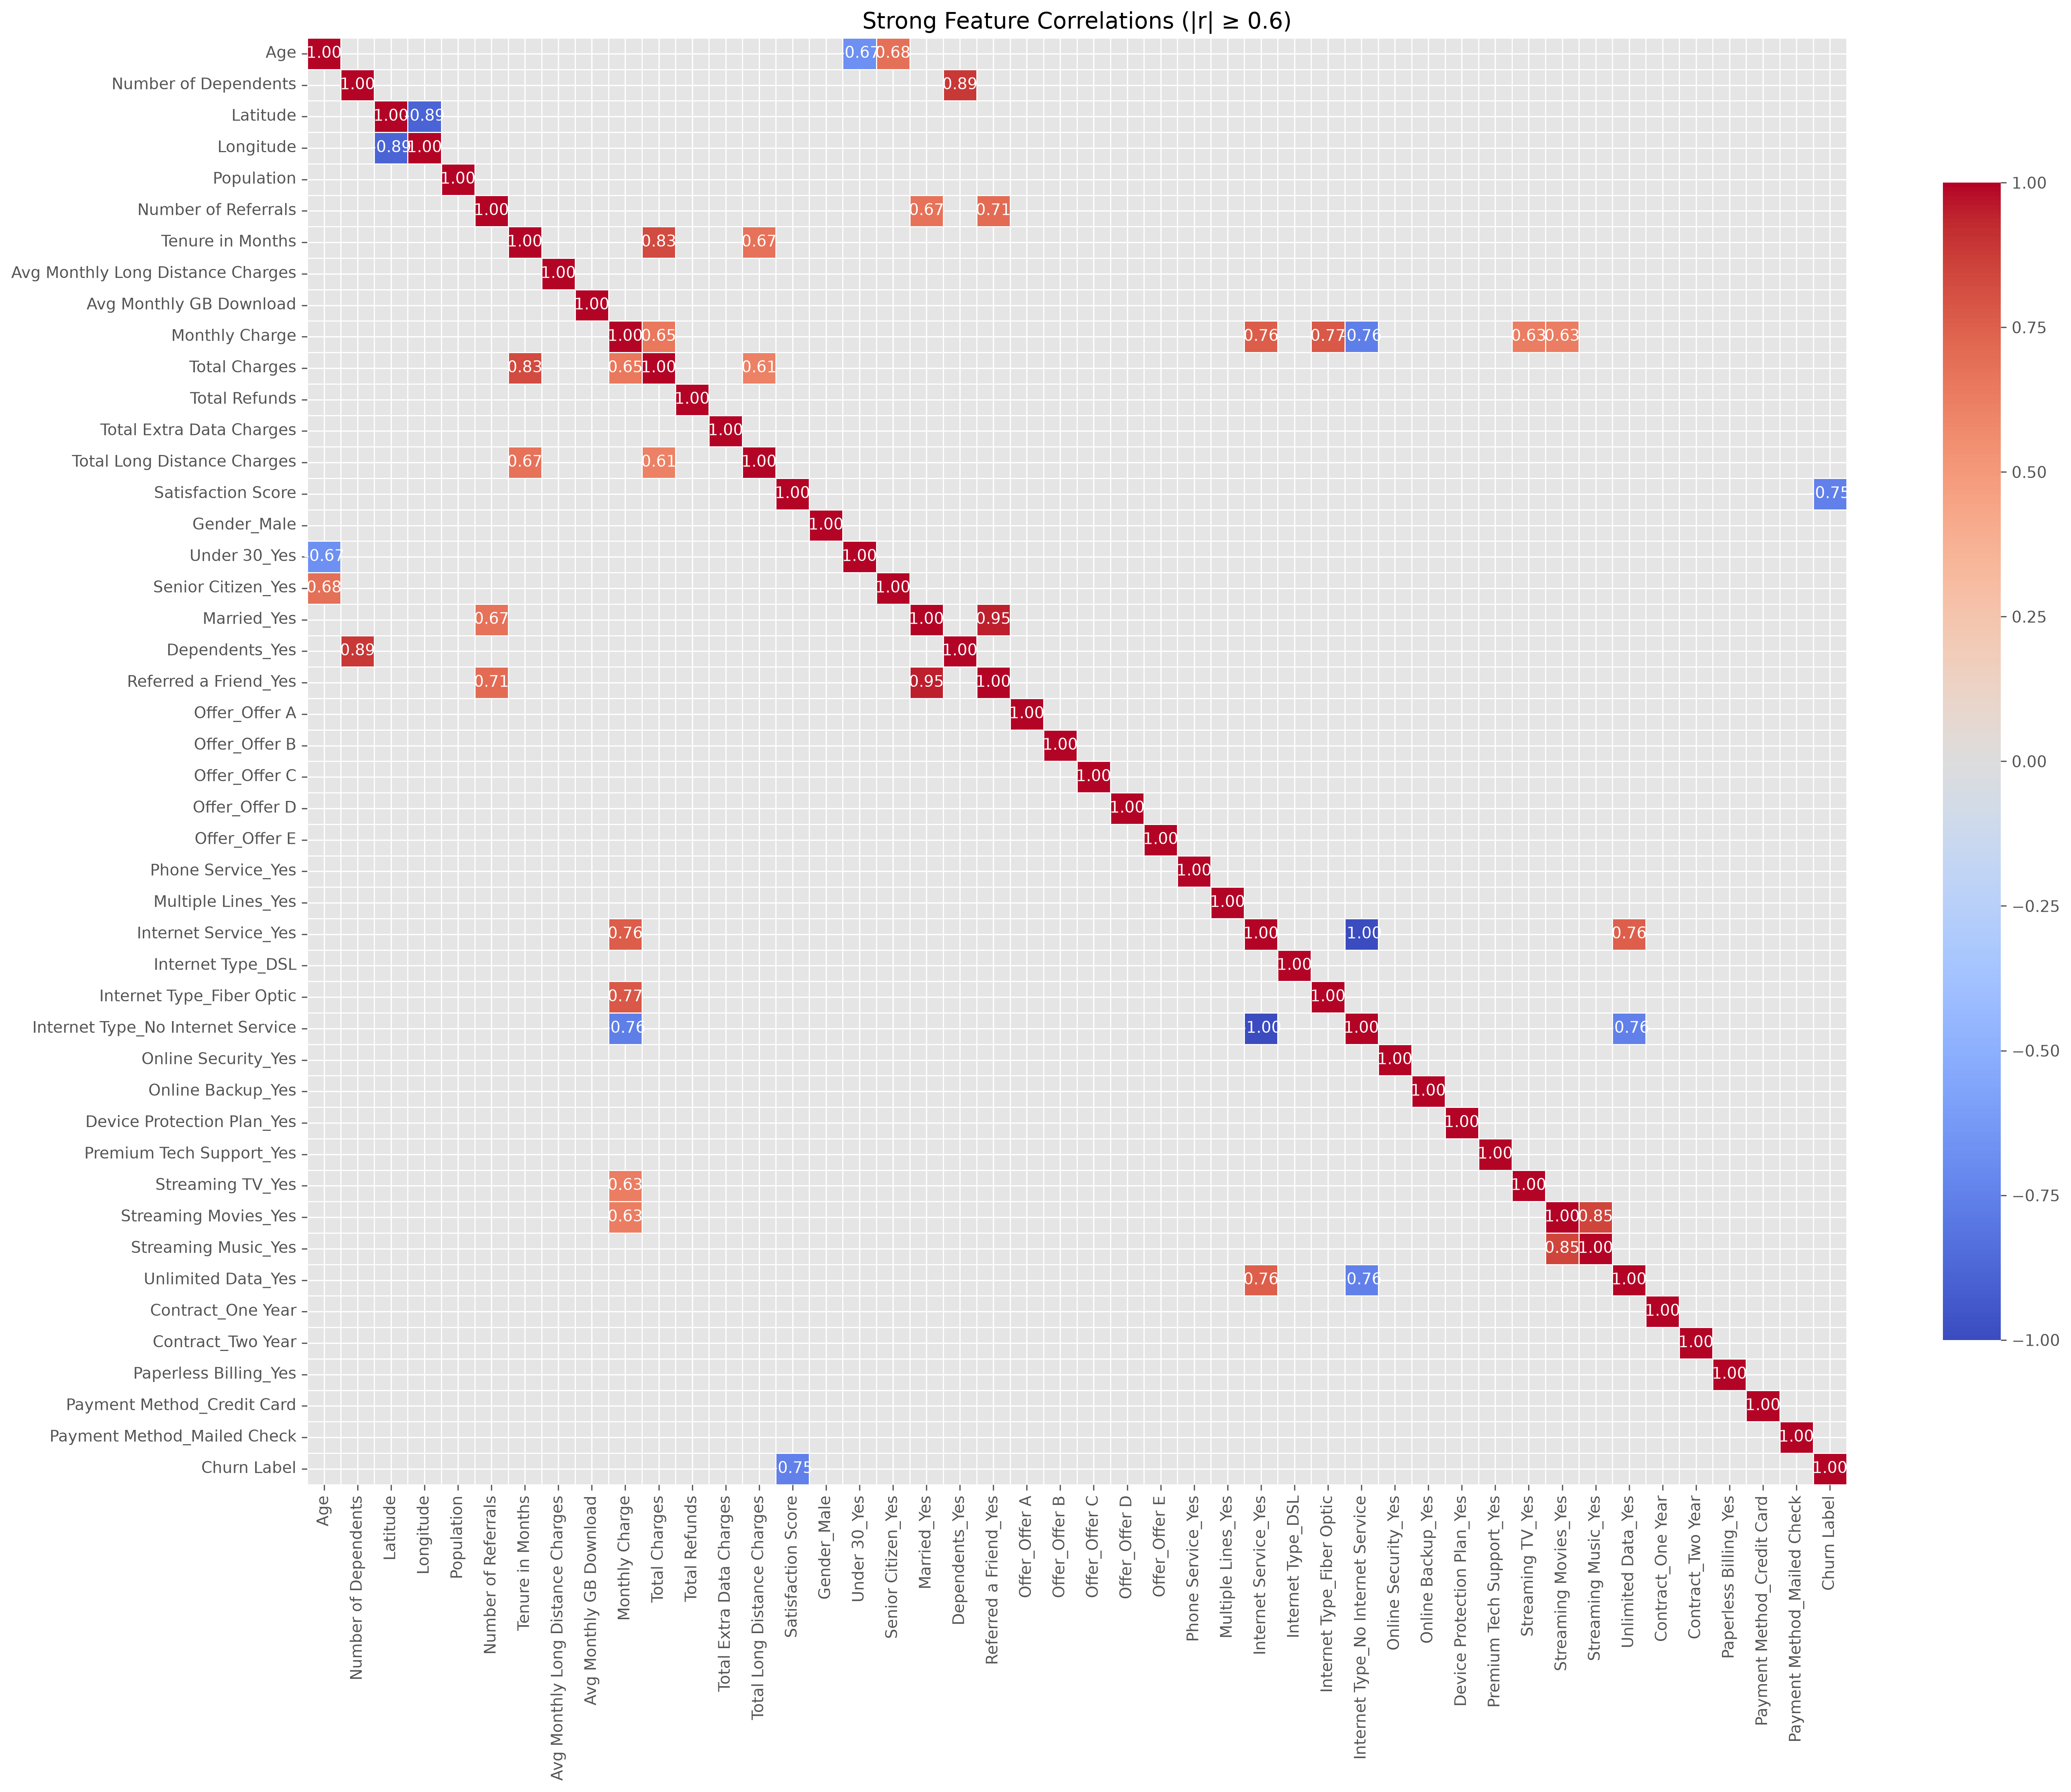

In [16]:
import numpy as np

corr_matrix = processed_data.corr(numeric_only=True)

# Keep only correlations above 0.6
mask = np.abs(corr_matrix) < 0.6

plt.figure(figsize=(20,16), dpi=300)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.3,
    cbar_kws={"shrink":0.8}
)

plt.title("Strong Feature Correlations (|r| ≥ 0.6)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np

# Correlation matrix
corr_matrix = processed_data.corr(numeric_only=True)

# Keep only upper triangle to avoid duplicates
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Convert to long format
corr_table = (
    upper.stack()
         .reset_index()
         .rename(columns={
             "level_0": "Feature 1",
             "level_1": "Feature 2",
             0: "Correlation"
         })
)

# Keep only strong correlations
threshold = 0.70

strong_corr = (
    corr_table[
        corr_table["Correlation"].abs() >= threshold
    ]
    .sort_values(by="Correlation", key=abs, ascending=False)
    .reset_index(drop=True)
)

print(strong_corr)

                            Feature 1                          Feature 2  \
0                Internet Service_Yes  Internet Type_No Internet Service   
1                         Married_Yes              Referred a Friend_Yes   
2                Number of Dependents                     Dependents_Yes   
3                            Latitude                          Longitude   
4                Streaming Movies_Yes                Streaming Music_Yes   
5                    Tenure in Months                      Total Charges   
6                      Monthly Charge          Internet Type_Fiber Optic   
7                      Monthly Charge               Internet Service_Yes   
8                      Monthly Charge  Internet Type_No Internet Service   
9   Internet Type_No Internet Service                 Unlimited Data_Yes   
10               Internet Service_Yes                 Unlimited Data_Yes   
11                 Satisfaction Score                        Churn Label   
12          